# Experiment 5
## Reinforcement Learning Using Python

**Name:** Ayush Gupta  
**SAP ID:** 500125537  
**Batch:** B7  
**Course:** Algorithms for Intelligent Systems and Robotics Lab

### 1. Aim
To implement Reinforcement Learning using Q-Learning in Python and train an agent to find the optimal path in a simple environment.

### 2. Objectives
- Understand the basic concept of Reinforcement Learning.
- Understand Agent, Environment, State, Action and Reward.
- Implement the Q-Learning algorithm using Python.
- Observe how an agent learns through trial and error.

### 3. Theory
Reinforcement Learning (RL) is a type of machine learning in which an agent learns by interacting with an environment.

The agent :
- observes the current state
- performs an action
- receives a reward or a penalty
- learns which actions produce better rewards

Q-Learning stores the expected reward of taking an action in a particular state using a **Q-table**. The Q value is updated using

$$Q(s, a) = Q(s, a) + \alpha \, [\, r + \gamma \, \max_{a'} Q(s', a') - Q(s, a) \,]$$

where
- $\alpha$ = learning rate
- $\gamma$ = discount factor
- $r$ = reward
- $s$ = current state
- $a$ = action
- $s'$ = next state

### 4. Requirements
Software : Python 3.x, NumPy, Jupyter Notebook / Google Colab

### 5. Algorithm
1. Initialize the Q-table with zeros.
2. Select the current state.
3. Choose an action using an exploration strategy.
4. Perform the action and observe the reward.
5. Update the Q-value.
6. Move to the next state.
7. Repeat until the goal is reached.
8. Train the agent for multiple episodes.
9. Display the learned optimal path.

### 6. Python Program

The environment is a 4x4 grid world. The 16 cells are numbered from 0 to 15 as shown below, the agent starts at state 0 and the goal is state 15.

```
 0   1   2   3
 4   5   6   7
 8   9  10  11
12  13  14  15
```

In [1]:
import numpy as np
import random

random.seed(42)      # keeping the same seed so that the output does not change every time

# 4x4 Grid World
# Start = 0, Goal = 15
states = 16
actions = 4        # 0=Up, 1=Down, 2=Left, 3=Right

Q = np.zeros((states, actions))

alpha = 0.8        # Learning rate
gamma = 0.95       # Discount factor
epsilon = 0.2      # Exploration rate
episodes = 1000

print("Q-table shape :", Q.shape)

Q-table shape : (16, 4)


The `next_state` function tells where the agent goes after taking an action. If the action takes it outside the grid then the row and the column are not changed, so the agent stays in the same cell.

In [10]:
def next_state(state, action):
    row, col = divmod(state, 4)

    if action == 0 and row > 0:        # Up
        row -= 1
    elif action == 1 and row < 3:      # Down
        row += 1
    elif action == 2 and col > 0:      # Left
        col -= 1
    elif action == 3 and col < 3:      # Right
        col += 1

    return row * 4 + col

# small check
print("from state 0 going right :", next_state(0, 3))
print("from state 0 going up    :", next_state(0, 0))   # not possible so it stays at 0

from state 0 going right : 1
from state 0 going up    : 0


**Training.** One episode means the agent starts from state 0 and keeps moving until it reaches state 15. In every step it either explores (random action) or exploits (best action from the Q-table), gets the reward and updates the Q value.

In [3]:
steps_per_episode = []      # extra, only for plotting the learning afterwards

# Training
for episode in range(episodes):
    state = 0
    steps = 0

    while state != 15:
        # Exploration or exploitation
        if random.random() < epsilon:
            action = random.randint(0, 3)
        else:
            action = np.argmax(Q[state])

        new_state = next_state(state, action)

        # Reward
        reward = 10 if new_state == 15 else -1

        # Q-learning update
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[new_state]) - Q[state, action]
        )

        state = new_state
        steps += 1

    steps_per_episode.append(steps)

print("training completed for", episodes, "episodes")

training completed for 1000 episodes


In [4]:
# Display learned path
state = 0
path = [state]

while state != 15:
    action = np.argmax(Q[state])
    state = next_state(state, action)
    path.append(state)

print("Learned Optimal Path:")
print(path)

Learned Optimal Path:
[0, 4, 8, 9, 13, 14, 15]


### 7. Output

The path printed above starts from state 0 and ends at state 15. The number of moves is 6, which is the minimum possible in a 4x4 grid because the agent has to go 3 cells down and 3 cells right in any case.

*Note : the exact path may vary depending on the training parameters and on the random seed, there are many paths of 6 moves and all of them are equally optimal.*

In [5]:
print("number of moves in the learned path :", len(path) - 1)
print("steps taken in the first episode     :", steps_per_episode[0])
print("steps taken in the last episode      :", steps_per_episode[-1])

number of moves in the learned path : 6
steps taken in the first episode     : 65
steps taken in the last episode      : 7


The Q-table after training. Every row is a state and every column is an action, the highest value in a row is the action which the agent will choose in that state.

The row of state 15 is still all zeros. That is correct, because state 15 is the goal and the episode finishes there, so no action is ever taken from it and its values are never updated.

In [6]:
np.set_printoptions(precision=2, suppress=True)
print("        up      down     left    right")
for s in range(16):
    print("state", str(s).rjust(2), Q[s])

        up      down     left    right
state  0 [2.05 3.21 2.05 3.21]
state  1 [3.16 4.44 2.05 4.43]
state  2 [-2.31  5.72  2.97  4.12]
state  3 [-1.57  7.07 -1.69 -1.57]
state  4 [2.05 4.44 3.21 4.44]
state  5 [3.21 5.72 3.21 5.72]
state  6 [4.44 7.07 4.44 7.07]
state  7 [ 5.35  8.5   5.54 -0.8 ]
state  8 [3.21 5.72 4.44 5.72]
state  9 [4.44 7.07 4.44 7.07]
state 10 [5.72 8.5  5.72 8.5 ]
state 11 [ 7.07 10.    7.07  8.5 ]
state 12 [4.44 5.43 5.72 7.07]
state 13 [5.72 7.07 5.72 8.5 ]
state 14 [ 7.07  8.5   7.07 10.  ]
state 15 [0. 0. 0. 0.]


Showing the learned path on the grid. Green is the start, yellow is the goal and the blue cells are the path taken by the trained agent.

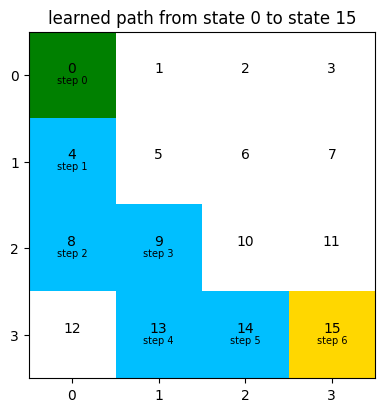

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['white', 'deepskyblue', 'green', 'gold'])

img = np.zeros((4,4))
for s in path:
    img[divmod(s, 4)] = 1
img[divmod(0, 4)]  = 2      # start
img[divmod(15, 4)] = 3      # goal

plt.figure(figsize=(4.5,4.5))
plt.imshow(img, cmap=cmap, vmin=0, vmax=3)

for s in range(16):
    r, cl = divmod(s, 4)
    plt.text(cl, r, str(s), ha='center', va='bottom', fontsize=10)
    if s in path:
        plt.text(cl, r, "step " + str(path.index(s)), ha='center', va='top', fontsize=7)

plt.title("learned path from state 0 to state 15")
plt.xticks(range(4)); plt.yticks(range(4))
plt.show()

Number of steps taken in each episode. The first episode is very long because the agent is moving almost blindly, and after that it drops immediately, since alpha = 0.8 means the agent accepts the new experience very fast.

The steps do not stay exactly at 6 after learning. This is because epsilon = 0.2, so even a fully trained agent still takes a random action in about one out of five moves, and those random moves add a few extra steps.

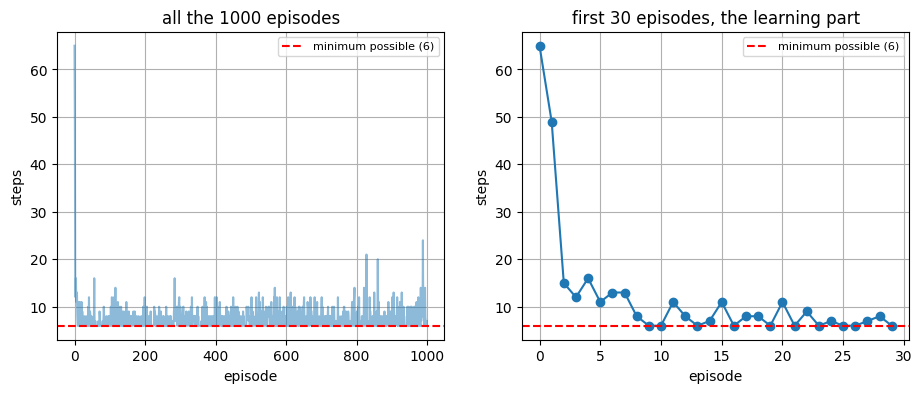

steps in the first episode             : 65
average steps in the first 5 episodes  : 31.4
average steps in the last 50 episodes  : 8.32
shortest episode during training       : 6


In [8]:
plt.figure(figsize=(11,4))

plt.subplot(1,2,1)
plt.plot(steps_per_episode, alpha=0.5)
plt.axhline(6, color='red', linestyle='--', label="minimum possible (6)")
plt.xlabel("episode"); plt.ylabel("steps")
plt.title("all the 1000 episodes")
plt.legend(fontsize=8); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(steps_per_episode[:30], 'o-')
plt.axhline(6, color='red', linestyle='--', label="minimum possible (6)")
plt.xlabel("episode"); plt.ylabel("steps")
plt.title("first 30 episodes, the learning part")
plt.legend(fontsize=8); plt.grid(True)

plt.show()

print("steps in the first episode             :", steps_per_episode[0])
print("average steps in the first 5 episodes  :", round(np.mean(steps_per_episode[:5]), 2))
print("average steps in the last 50 episodes  :", round(np.mean(steps_per_episode[-50:]), 2))
print("shortest episode during training       :", min(steps_per_episode))

The Q-table has 64 numbers so it is easier to understand it as a picture. For every state the value of the best action, V(s) = max Q(s, a), is plotted as a heatmap, and the best action itself is drawn as an arrow.

In [ ]:
V = np.max(Q, axis=1).reshape(4, 4)
V[3, 3] = np.nan          # goal is terminal, it has no value of its own

plt.figure(figsize=(11,5))

plt.subplot(1,2,1)
plt.imshow(V, cmap='YlGn')
plt.colorbar(label="V(s) = max Q(s, a)")
for s in range(16):
    r, cl = divmod(s, 4)
    if s == 15:
        plt.text(cl, r, "GOAL", ha='center', va='center', fontsize=9)
    else:
        plt.text(cl, r, round(np.max(Q[s]), 2), ha='center', va='center', fontsize=10)
plt.title("value of every state")
plt.xticks(range(4)); plt.yticks(range(4))

plt.subplot(1,2,2)
plt.imshow(np.zeros((4,4)), cmap='Greys', vmin=0, vmax=1)
moves = {0:(0,-0.3), 1:(0,0.3), 2:(-0.3,0), 3:(0.3,0)}    # dx, dy for each action
for s in range(16):
    r, cl = divmod(s, 4)
    if s == 15:
        plt.text(cl, r, "GOAL", ha='center', va='center', fontsize=9, color='green')
        continue
    a = int(np.argmax(Q[s]))
    dx, dy = moves[a]
    plt.arrow(cl - dx/2, r - dy/2, dx, dy, head_width=0.14, color='blue')
plt.title("best action in every state (the policy)")
plt.xticks(range(4)); plt.yticks(range(4))
plt.grid(color='gray', linewidth=0.4)

plt.show()

The values are the smallest at the start and keep increasing towards the goal, because of the discount factor gamma the reward of +10 becomes smaller and smaller as we move away from state 15. The arrows show that from every cell the agent moves either down or right, which is the correct policy for this grid.

Reward obtained in each episode. It is not stored seperately, it can be calculated from the number of steps itself, because an episode of n steps has n-1 ordinary moves of -1 and one final move of +10, so

total reward = 10 - (n - 1) = 11 - n

In [ ]:
episode_reward = [11 - n for n in steps_per_episode]

plt.figure(figsize=(8,4))
plt.plot(episode_reward, alpha=0.5)
plt.axhline(5, color='red', linestyle='--', label="best possible (6 steps, reward 5)")
plt.xlabel("episode"); plt.ylabel("total reward")
plt.title("reward per episode")
plt.legend(fontsize=8); plt.grid(True)
plt.show()

print("reward in the first episode           :", episode_reward[0])
print("average reward of the last 50 episodes:", round(np.mean(episode_reward[-50:]), 2))
print("best possible reward                  :", 11 - 6)

### 8. Result
The Q-Learning algorithm was successfully implemented in Python, and the agent learned an optimal path from the starting state to the goal through repeated interaction with the environment.

The Q-table which was initialised with zeros gradually filled up with the expected rewards, and the greedy policy taken from this table gives a path of 6 moves from state 0 to state 15, which is the shortest possible path in a 4x4 grid.

The learning can also be seen in the number of steps per episode. The first episode took 65 steps because the agent was moving almost randomly, and within a few episodes it came down to nearly the minimum. It does not become exactly 6 during training because the exploration rate is kept fixed at 0.2, so one out of five moves is still random, but the final path taken by the greedy policy is exactly 6 moves.

### 9. Conclusion
Reinforcement learning was implemented using the Q-Learning algorithm and an agent was trained to find the optimal path in a 4x4 grid world.

The experiment shows that the agent is able to learn the correct behaviour only from the rewards returned by the environment. It is never told where the goal is or which action is correct, and still, after repeated interaction, the Q-table which was initialised with zeros contains the expected reward of every state and action pair, and the greedy policy obtained from this table gives the shortest path of six moves from state 0 to state 15.

The values stored in the table also show the effect of the discount factor. The value of a state increases as the state comes closer to the goal, since the reward of +10 is multiplied by gamma once for every additional step of distance, and the policy formed by taking the best action of every state points towards the goal from every cell of the grid.

The number of steps per episode came down from 65 in the first episode to nearly the minimum within a few episodes, which is fast because the learning rate is kept high at 0.8. The steps do not remain exactly at the minimum during the training since the exploration rate is fixed at 0.2, and one move out of five is taken randomly even after the agent has learnt.

It is concluded that Q-Learning is a simple and effective model free method for problems having a small and discrete state space. For larger environments the size of the Q-table grows very quickly and storing it becomes impractical, and in such cases function approximation methods such as Deep Q Networks are used.

### 10. Some important questions

**1. What is Reinforcement Learning ?**  
It is a type of machine learning in which an agent learns by interacting with an environment. There is no dataset of correct answers, the agent tries different actions and learns from the rewards and penalties it receives.

**2. What is an agent and an environment ?**  
The agent is the learner or the decision maker, here it is the robot moving in the grid. The environment is everything outside the agent, here it is the 4x4 grid which gives the next state and the reward.

**3. What is a reward ?**  
It is the number returned by the environment after every action, and it tells how good that action was. In this program reaching the goal gives +10 and every other move gives -1 so that the agent learns a short path.

**4. What is Q-Learning ?**  
It is a model free reinforcement learning algorithm which learns the value Q(s,a) of taking an action a in a state s. Model free means the agent does not need to know the rules of the environment in advance.

**5. What is the purpose of a Q-table ?**  
It stores the expected future reward for every state and action pair. After training, the best action in a state is simply the action having the maximum value in that row of the table.

**6. What is the difference between exploration and exploitation ?**  
Exploration means taking a random action to find out something new, exploitation means taking the action which is best according to the current Q-table. If the agent only exploits it may never find a better path, and if it only explores it never uses what it has learnt. In this program epsilon = 0.2 means the agent explores 20 percent of the time.

**7. What do alpha and gamma represent ?**  
Alpha is the learning rate, it decides how much of the new experience is used while updating the old value. Gamma is the discount factor, it decides how much importance is given to the future rewards compared to the immediate reward. Here alpha = 0.8 and gamma = 0.95, so the learning is fast and the future rewards are given almost equal importance.